In [73]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from tqdm import tqdm
from glob import glob
import re
import os 
from vader import sentiment_vader
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
import pickle
import scipy as sp

In [5]:
import warnings
warnings.filterwarnings('ignore')
debug = False

In [6]:
Verified_profile_tweets = pd.DataFrame()
Unverified_perfoile_tweets = pd.DataFrame()

In [7]:
def read_csv(path):
    df = pd.read_csv(path, index_col = ['Unnamed: 0'])
    df.drop(['retweetedTweet', 'quotedTweet', 'place'], axis = 1,inplace =True)
    df['date'] = pd.to_datetime(df['date'])
    df['Date'] = df['date'].dt.date
    df['Time'] = df['date'].dt.time
    df.drop(['date'],axis = 1, inplace =True)
    return df

In [8]:
def df_info(df):
    print(df.head())
    print('\n')
    print(df.describe())
    print('\n')
    print(df.isnull().sum())

In [9]:
def ver_prof_tweet_ext(df):
    return df[df['profile_verified_status'] == True]

In [10]:
def Non_ver_prof_tweet_ext(df):
    return df[df['profile_verified_status'] == False]

In [11]:
def cleanTweet(tweet):
    tweet = re.sub('#[A-Za-z0-9]+', '', tweet) # Removes all words starting with #
    tweet = re.sub('@[A-Za-z0-9]+', '', tweet) # Removes all words starting with @
    tweet = re.sub('\\n', '', tweet) # Pretends from breaking the tweet
    tweet = re.sub('https?:\/\/\S+', '', tweet) # Removes hyperlinks
    return tweet

In [12]:
def bot_tweet_ids(df):
    user_counts = df["user_name"].value_counts()
    lst = []
    tweet_idxs = []
    for item in user_counts.index:
        if user_counts[item] > 3:
            lst.append(item)
    for item in lst:
        bot_twt = df[df['user_name'] == item]
        tweet_idxs.append(bot_twt.index)
    return tweet_idxs

In [13]:
def tweet_preprocessing(df):
    before_len = len(df)
    dates = df['Date'].unique()
    for date in tqdm(dates):
        df_day = df[df['Date'] == date]
        idxs = bot_tweet_ids(df_day)
        for item in idxs:
            df.drop(index = item, axis =0, inplace =True)
    df['content'] = df['content'].apply(lambda x: cleanTweet(x))
    after_len = len(df)
    print("Before and After Tweets:",before_len,after_len)
    return df

In [14]:
def sentiment_ext(df):
    df['sentiment'] = df['content'].apply(lambda x: sentiment_vader(x))
    sentiment= {}
    for index, row in df.iterrows():
        sentiment[index] = {'date': pd.to_datetime(row['Date']),
                             'negative':row['sentiment'][0], 
                             'neutral':row['sentiment'][1], 
                             'positive':row['sentiment'][2], 
                             'compound':row['sentiment'][3], 
                             'overall_sentiment':row['sentiment'][4],
                             'like': row['likes_count'],
                             'retweets': row['retweet_count']}
    return pd.DataFrame.from_dict(sentiment, orient='index')

In [15]:
def sentiment_analysis(senti_df):
    positive_df = senti_df[senti_df['overall_sentiment'] == 'Positive']
    neagtive_df = senti_df[senti_df['overall_sentiment'] == 'Negative']
    neutral_df  = senti_df[senti_df['overall_sentiment'] == 'Neutral']
    senti_dict  =     { 
                        'Positive_count': len(positive_df.index),
                        'Positive_likes': positive_df['like'].sum(),
                        'Positive_retweets': positive_df['retweets'].sum(),
                        'Average_positive_index': positive_df['positive'].mean(),
                        'Average_pos_compound_index': positive_df['compound'].mean(),
                        'Negative_count': len(neagtive_df.index),
                        'Negative_likes': neagtive_df['like'].sum(),
                        'Negative_retweets': neagtive_df['retweets'].sum(),
                        'Average_Negative_index': neagtive_df['positive'].mean(),
                        'Average_neg_compound_index': neagtive_df['compound'].mean(),
                        'Neutral_count': len(neutral_df.index),
                        'Neutral_likes': neutral_df['like'].sum(),
                        'Neutral_retweets': neutral_df['retweets'].sum(),
                        'Average_Neutral_index': neutral_df['positive'].mean(),
                        'Average_neu_compound_index': neutral_df['compound'].mean()
                       }
    
    return senti_dict

In [16]:
def bar_plot(pos_v, neg_v, neut_v, index = None, width = 0.2, title = 'Tweets During the Jan 2020 and Dec 2020', 
             xlabel = 'Duration', ylabel = 'Tweets count', name = 'fig2.png'):
    if index is None:
        index = [x for x in len(pos_v)]
    plt.figure(figsize=(20,7))
    plt.bar(index-width, pos_v, width, label = 'Positive', color= ['green'])
    plt.bar(index, neg_v, width, label = 'Negative', color= ['red'])
    plt.bar(index+width, neut_v, width, label = 'Neutral', color= ['blue'])
    plt.title(title)
    plt.xticks(index)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.savefig(name)
    plt.show()

In [81]:
def average_post_reach(df):
    reach_4m_average_likes = []
    reach_4m_average_rtwts = []
    for index, row in df.iterrows():
        if (row['Positive_likes'] + row['Negative_likes']) > 0:
            reach_4m_average_likes.append((row['Positive_likes'] - row['Negative_likes'])/(row['Positive_likes'] + row['Negative_likes']))
        else:
            reach_4m_average_likes.append(0)
        if (row['Positive_retweets'] + row['Negative_retweets']) >0:
            reach_4m_average_rtwts.append((row['Positive_retweets'] - row['Negative_retweets'])/(row['Positive_retweets'] + row['Negative_retweets']))
        else:
            reach_4m_average_rtwts.append(0)
    reach_4m_average_likes = [0 if math.isnan(x) else x for x in reach_4m_average_likes]
    reach_4m_average_rtwts = [0 if math.isnan(x) else x for x in reach_4m_average_rtwts]
    return reach_4m_average_likes, reach_4m_average_rtwts

In [82]:
def average_post_reach2(df):
    reach_4m_average_likes = []
    reach_4m_average_rtwts = []
    for index, row in df.iterrows():
        avg_pos_lks = row['Positive_likes']/row['Positive_count']
        avg_neg_lks = row['Negative_likes']/row['Negative_count']
        reach_4m_average_likes.append((avg_pos_lks - avg_neg_lks)/(avg_pos_lks + avg_neg_lks))
        reach_4m_average_rtwts.append((row['Positive_retweets'] - row['Negative_retweets'])/(row['Positive_retweets'] + row['Negative_retweets']))
    reach_4m_average_likes = [0 if math.isnan(x) else x for x in reach_4m_average_likes]
    reach_4m_average_rtwts = [0 if math.isnan(x) else x for x in reach_4m_average_rtwts]
    return reach_4m_average_likes, reach_4m_average_rtwts 

In [83]:
def line_graph(x, y, z, title = 'Tweets During the Jan 2020 and Dec 2020',label1 = 'Reach_via_likes', label2 = 'Reach_via_retweets', 
               label3 = 'Average price change', xlabel = 'Duration', ylabel = 'Reach and price', name = 'fig1.png'):
    plt.figure(figsize = (20,7))
    plt.plot(x, 'bo-', label= label1)
    plt.plot(y, 'ro-', label = label2)
    plt.plot(z, 'go-', label = label3)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.savefig(name)
    plt.show()

In [84]:
def percent_change(df, variable, count):
    change = []
    lst = list(df[variable])
    lst2 = list(df[count])
    for i in range(len(lst)-1):
        if lst2[i+1] == 0:
            lst2[i+1] = 1
        if lst2[i] == 0:
            lst2[i] = 1
        cur = lst[i+1]/lst2[i+1]
        pst = lst[i]/lst2[i]
        if pst ==0:
            pst =1
        #change.append(((lst[i+1]- lst[i])/lst[i]))
        change.append((cur-pst)/pst)
    return change

In [85]:
def plotting_sentiment(senti_df, avg_price, duration = 'Duration', asset='Bitcoin', prof = 'Ver_prof'):
    name = asset+'_'+prof+'_'+duration+'_'
    bar_plot(senti_df['Positive_count'], senti_df['Negative_count'], senti_df['Neutral_count'], 
             index = senti_df.index,title = 'Various sentiment tweet distribution during Jan 2020 and Dec 2020', 
             xlabel = duration, ylabel ='Tweet count', name = name+'senti.png')
    avg_likes, avg_rtwts = average_post_reach(senti_df)
    pos_likes_chng = percent_change(senti_df, 'Positive_likes', 'Positive_count')
    neg_likes_chng = percent_change(senti_df, 'Negative_likes', 'Negative_count')
    neut_likes_chng =percent_change(senti_df, 'Neutral_likes', 'Neutral_count')
    avg_price = list(avg_price)
    
    line_graph(avg_likes, avg_rtwts, avg_price, title= 'Post reach w.r.t to likes and retweets', xlabel = duration, ylabel = 'reach', name = name+'reach_vs_price.png')
    corr1 = sp.stats.pearsonr(avg_likes, avg_price)
    corr2 = sp.stats.pearsonr(avg_rtwts, avg_price)
    avg_price.pop(0)
    line_graph(pos_likes_chng, neg_likes_chng, avg_price, label1 ='prcnt chng in Pos likes',
             label2 ='prcnt chng in Neg likes', label3 ='price chng duration', title = 'Change in likes received by multiple sentiment', ylabel = 'Percentage change',
              name = name+'change_vs_price.png', xlabel = duration)
    print("corelation of price wrt to avg likes: ",corr1) 
    print("corelation of price wrt to avg retweets: ",corr2)
    corr3 = sp.stats.pearsonr(pos_likes_chng, avg_price)
    corr4 = sp.stats.pearsonr(neg_likes_chng, avg_price)
    print("corelation of price wrt to avg positive likes reach: ",corr3) 
    print("corelation of price wrt to avg negative likes reach: ",corr4)

In [86]:
week_dates={}
year = 2020
for week in tqdm(range(1, 52)):
    date = datetime.date(year, 1, 1) + relativedelta(weeks=+week)
    start = date - timedelta(days=date.weekday())
    end = start + timedelta(days=6)
    week_dates[week]= [start, end]

100%|███████████████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 51015.86it/s]


In [87]:
asset_dict = pickle.load(open('crypto_asset_price_info.p','rb'))

## __Sentiment & Trend Analysis__

In [147]:
asset = 'bitcoin'

In [148]:
for index, files in enumerate(glob("tweets_"+asset+"*")):
    df = read_csv(files)
    if debug == True:
        df_info(df)
    if index == 0:
        Verified_profile_tweets  = ver_prof_tweet_ext(df).copy(deep=True)
        Unverified_perfoile_tweets = Non_ver_prof_tweet_ext(df).copy(deep=True)
    else:
        Verified_profile_tweets = pd.concat([Verified_profile_tweets, ver_prof_tweet_ext(df)],ignore_index=True)
        Unverified_perfoile_tweets = pd.concat([Unverified_perfoile_tweets, Non_ver_prof_tweet_ext(df)],ignore_index=True)

In [149]:
Verified_profile_tweets = tweet_preprocessing(Verified_profile_tweets)

100%|████████████████████████████████████████████████████████████████████████████████| 357/357 [00:22<00:00, 15.56it/s]


Before and After Tweets: 56544 40450


In [150]:
Unverified_perfoile_tweets = tweet_preprocessing(Unverified_perfoile_tweets)

100%|████████████████████████████████████████████████████████████████████████████████| 357/357 [02:32<00:00,  2.35it/s]


Before and After Tweets: 206544 174104


In [151]:
Unverified_perfoile_tweets.set_index('id')
print('')

In [152]:
senti_df_vp = sentiment_ext(Verified_profile_tweets)

In [153]:
month_info = {}
for month in range(1,13):
    month_df = senti_df_vp[senti_df_vp['date'].dt.month == month]
    month_info[month] = sentiment_analysis(month_df)
month_df_vp = pd.DataFrame.from_dict(month_info, orient='index')   

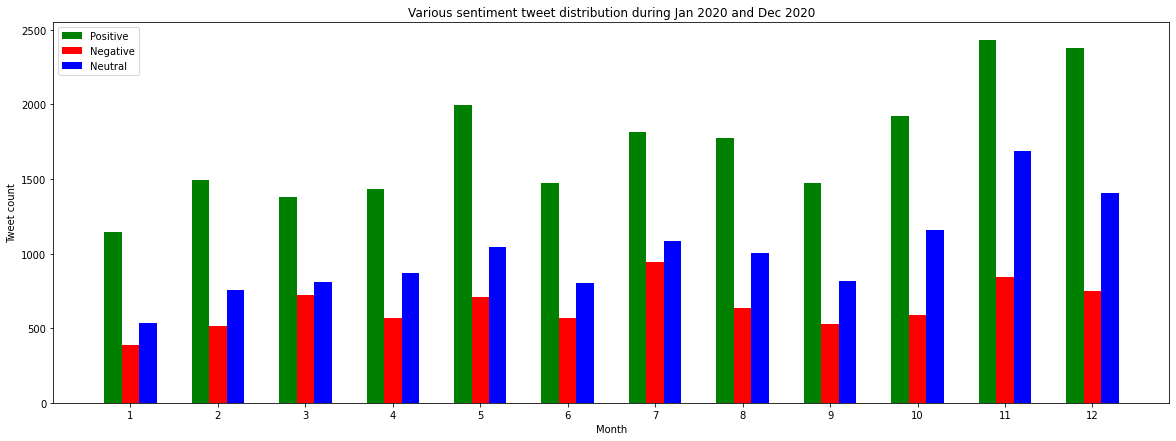

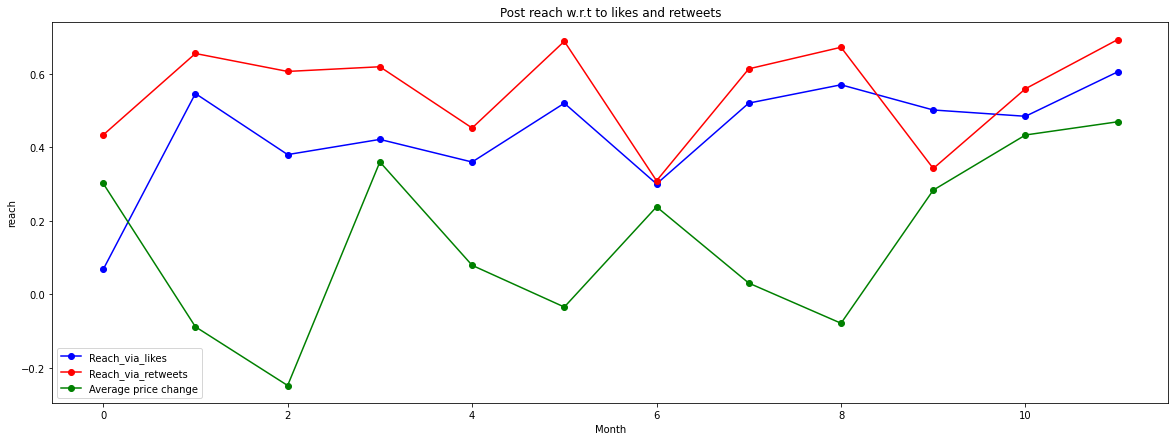

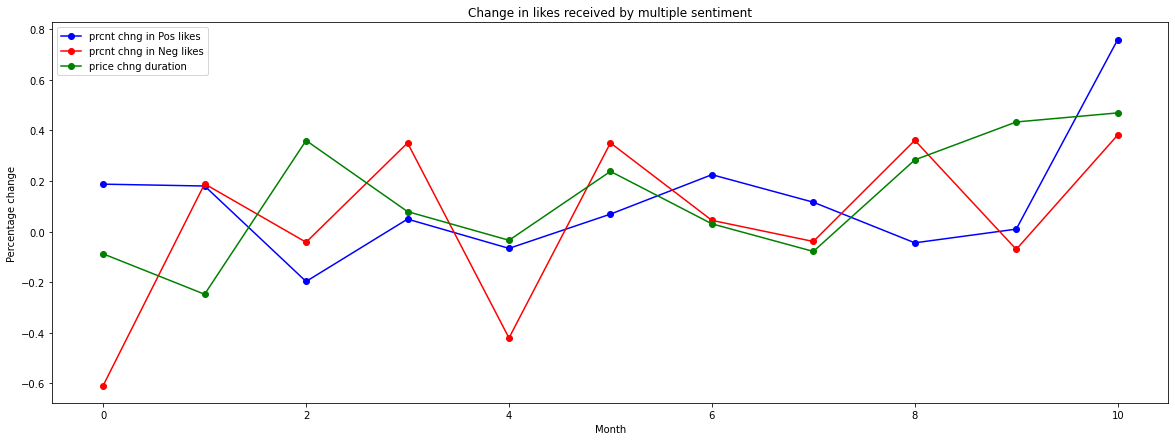

corelation of price wrt to avg likes:  PearsonRResult(statistic=-0.1289444506712353, pvalue=0.6896060566623825)
corelation of price wrt to avg retweets:  PearsonRResult(statistic=-0.30339136442949644, pvalue=0.337740982546635)
corelation of price wrt to avg positive likes reach:  PearsonRResult(statistic=0.1135178540124614, pvalue=0.7396418254164767)
corelation of price wrt to avg negative likes reach:  PearsonRResult(statistic=0.3902980713154413, pvalue=0.23533703076466872)


In [162]:
plotting_sentiment(month_df_vp, asset_dict['bitcoin']['m_df']['Percent_price_change'], duration = 'Month', asset=asset, prof = 'Ver_prof')

In [155]:
week_info = {}
for week in week_dates.keys():
    week_df = senti_df_vp[(senti_df_vp['date'].dt.date>=week_dates[week][0]) & (senti_df_vp['date'].dt.date<=week_dates[week][1])]
    week_info[week] = sentiment_analysis(week_df)
week_df_vp = pd.DataFrame.from_dict(week_info, orient='index')

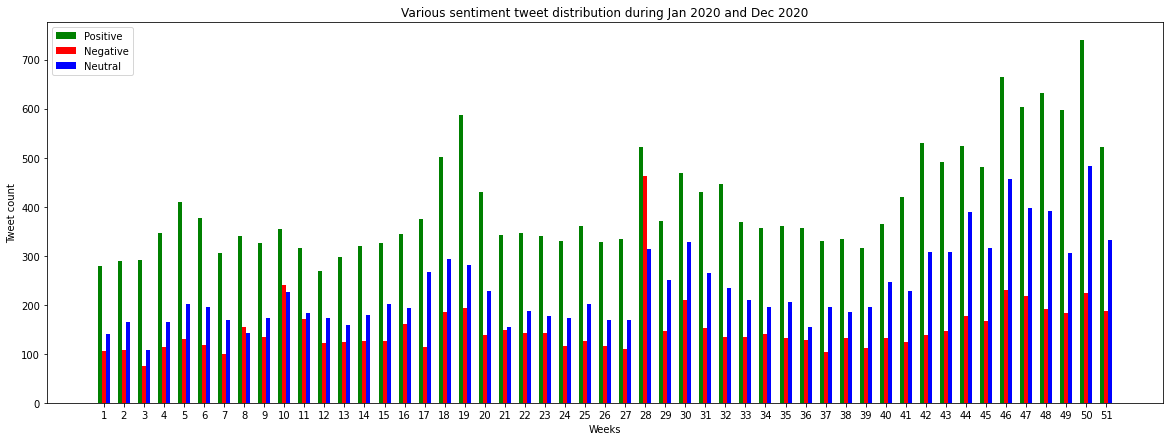

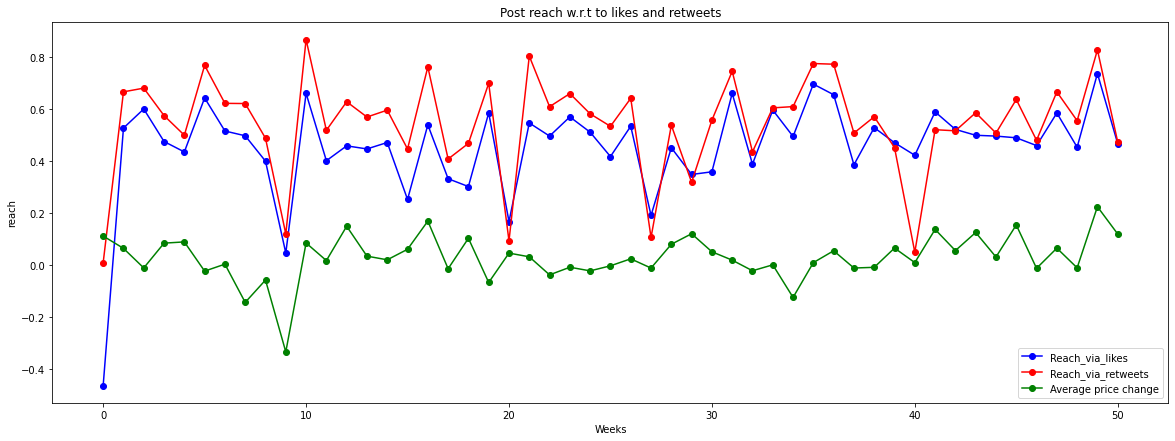

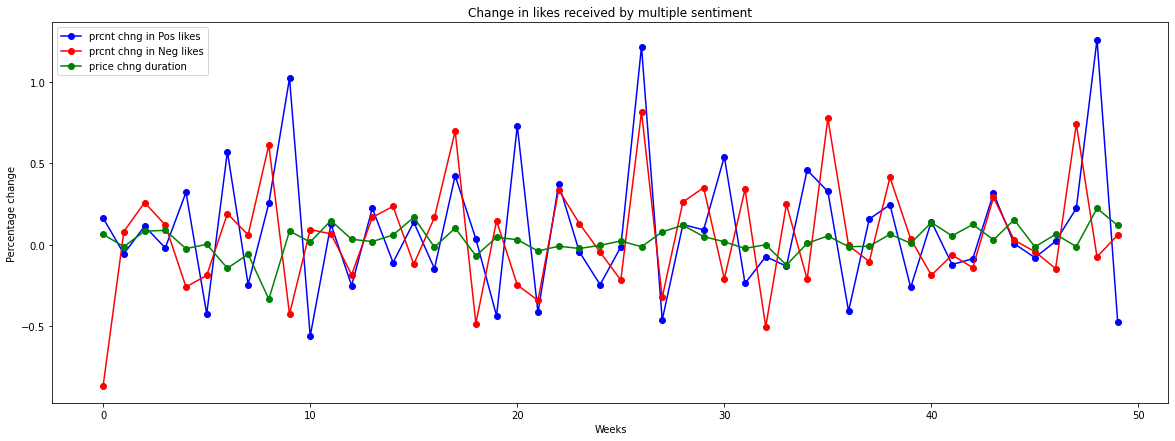

corelation of price wrt to avg likes:  PearsonRResult(statistic=0.1435396954282623, pvalue=0.31495400791186523)
corelation of price wrt to avg retweets:  PearsonRResult(statistic=0.20407222876739126, pvalue=0.15088767936380756)
corelation of price wrt to avg positive likes reach:  PearsonRResult(statistic=0.10619559349199378, pvalue=0.46294702785597397)
corelation of price wrt to avg negative likes reach:  PearsonRResult(statistic=-0.18202752551952223, pvalue=0.2058087385750242)


In [163]:
plotting_sentiment(week_df_vp, asset_dict['bitcoin']['w_df']['Percent_price_change'], duration = 'Weeks', asset=asset, prof = 'Ver_prof')

In [157]:
unfp_senti_df = sentiment_ext(Unverified_perfoile_tweets)

In [158]:
month_info = {}
for month in range(1,13):
    month_df = unfp_senti_df[unfp_senti_df['date'].dt.month == month]
    month_info[month] = sentiment_analysis(month_df)
month_df_unvp = pd.DataFrame.from_dict(month_info, orient='index')

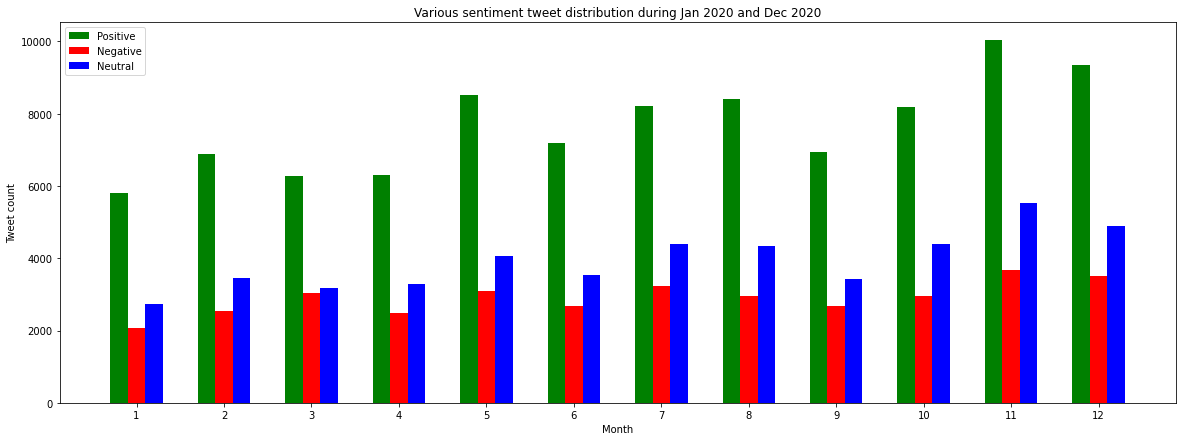

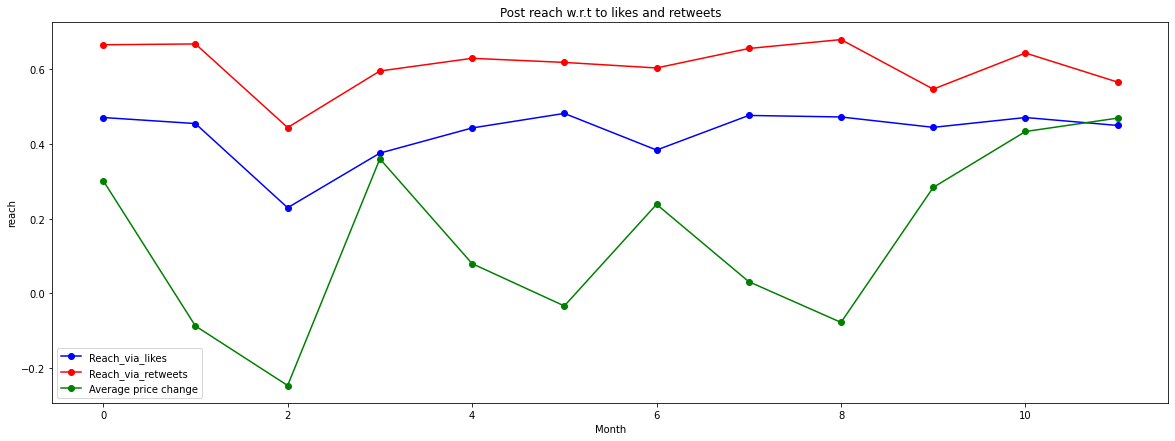

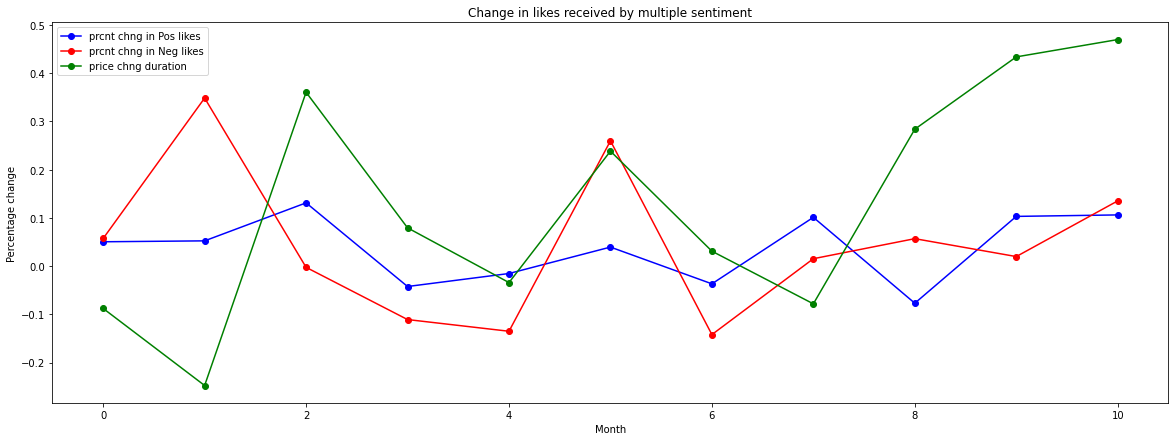

corelation of price wrt to avg likes:  PearsonRResult(statistic=0.3194656934462213, pvalue=0.3114387073331269)
corelation of price wrt to avg retweets:  PearsonRResult(statistic=0.115608606852603, pvalue=0.7205038666235812)
corelation of price wrt to avg positive likes reach:  PearsonRResult(statistic=0.2717110680202768, pvalue=0.4189484950954229)
corelation of price wrt to avg negative likes reach:  PearsonRResult(statistic=-0.048471896715488946, pvalue=0.887456069196967)


In [164]:
plotting_sentiment(month_df_unvp,asset_dict['bitcoin']['m_df']['Percent_price_change'], duration = 'Month', asset=asset, prof = 'Unver_prof')

In [160]:
week_info = {}
for week in week_dates.keys():
    week_df = unfp_senti_df[(unfp_senti_df['date'].dt.date>=week_dates[week][0]) & (unfp_senti_df['date'].dt.date<=week_dates[week][1])]
    week_info[week] = sentiment_analysis(week_df)
week_df_unvp = pd.DataFrame.from_dict(week_info, orient='index')

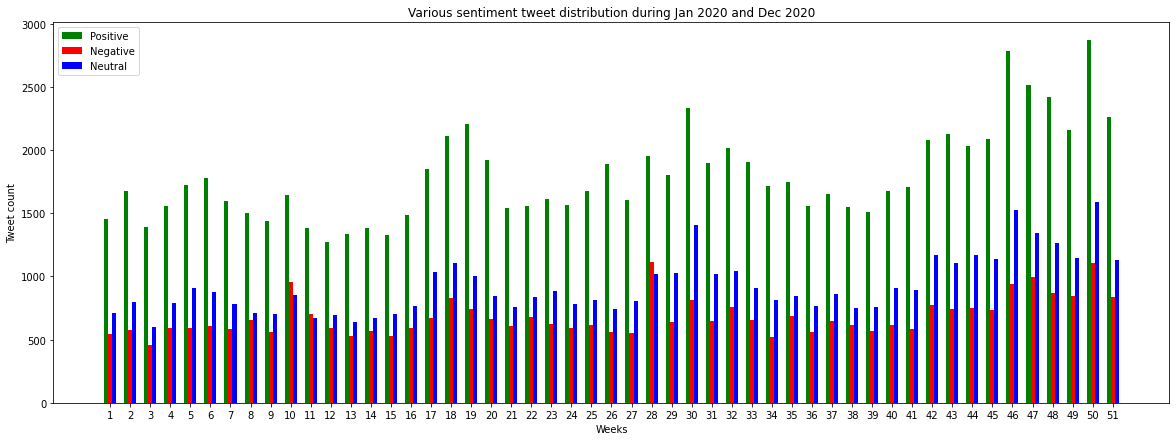

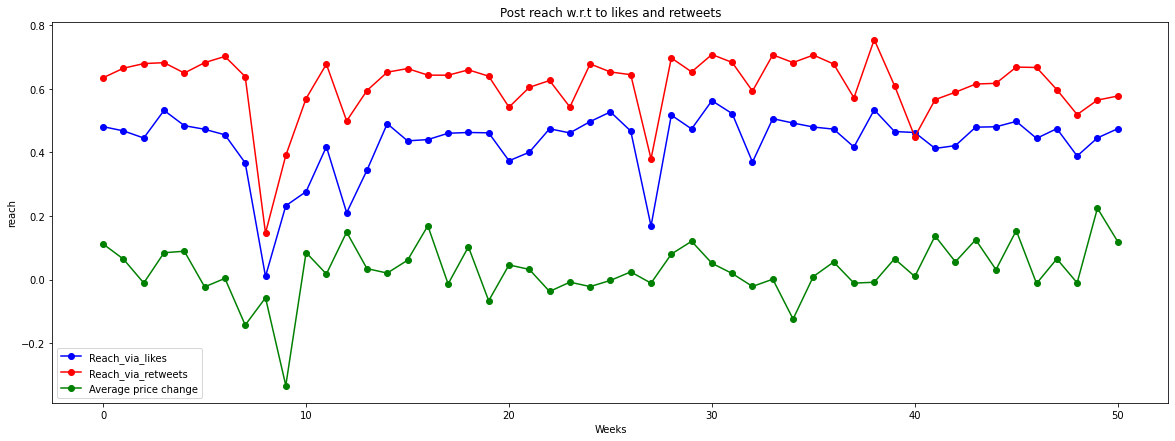

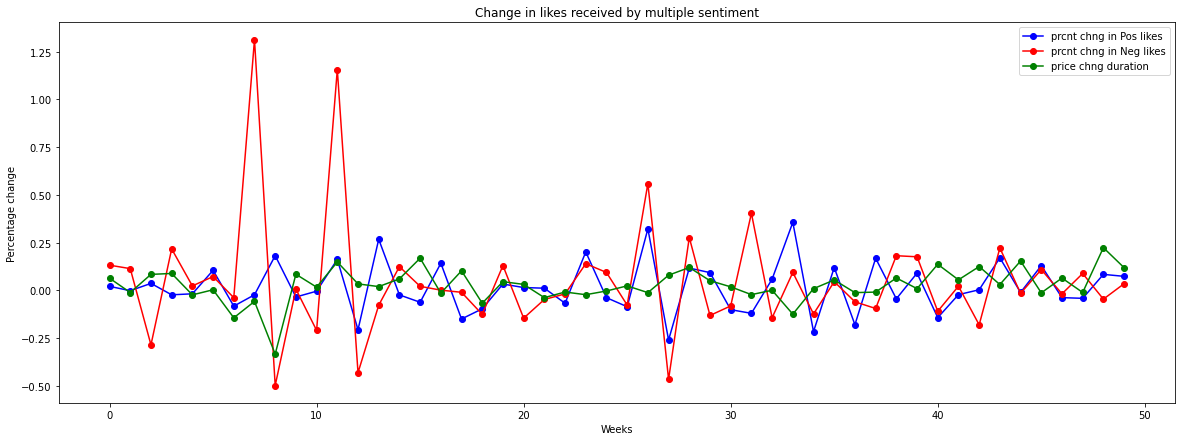

corelation of price wrt to avg likes:  PearsonRResult(statistic=0.2563138791583851, pvalue=0.06944247826837356)
corelation of price wrt to avg retweets:  PearsonRResult(statistic=0.21764360899447496, pvalue=0.12497795336017577)
corelation of price wrt to avg positive likes reach:  PearsonRResult(statistic=-0.20167622714346975, pvalue=0.16017725792538368)
corelation of price wrt to avg negative likes reach:  PearsonRResult(statistic=0.10374510248622612, pvalue=0.47339121199149076)


In [165]:
plotting_sentiment(week_df_unvp, asset_dict['bitcoin']['w_df']['Percent_price_change'],duration = 'Weeks', asset=asset, prof = 'Unver_prof')